# Genesis Potential Index (GPI) demo (EXPERIMENTAL)

This notebook demonstrates the **experimental** `tcpyPI.genesis_potential_index()` utility with a transparent, step-by-step single-column example.

## Scientific basis / citations

This implementation provides two common *published* GPI variants behind a switch:
- `en04`: Emanuel & Nolan (2004)
- `c07`: Camargo et al. (2007) variant with PI thresholding

**As implemented in `tcpyPI.gpi`**, the index combines:
- low-level absolute vorticity magnitude `|η|` (s⁻¹; commonly 850 hPa)
- midlevel relative humidity `RH` (%; commonly ~700 hPa)
- deep-layer shear magnitude `Vshear` (m/s; commonly 850–200 hPa)
- potential intensity `V_PI` (m/s; from `tcpyPI.pi`)

The exact functional form in this code is:

- `en04`:

$$\mathrm{GPI} = (10^5|\eta|)^3\,(RH/50)^3\,(V_{PI}/70)^3\,(1+0.1\,V_{shear})^{-2}$$

- `c07` (PI thresholding):

$$\mathrm{GPI} = (10^5|\eta|)^3\,(RH/50)^3\,(\max(V_{PI}-35,0)/70)^3\,(1+0.1\,V_{shear})^{-2}$$

Published GPIs differ in details (variable definitions, levels, and sometimes exponents/normalizations). Treat the equations above as the authoritative definition for the values produced by this package.

## What magnitude should you expect?

GPI is **unitless** and **not a probability**. Its magnitude is best interpreted **relative** (spatial/seasonal comparisons) and can vary by **orders of magnitude** depending on the inputs.

In this notebook’s single-column example, using:
- `|η| = 2e-5 s^-1` (so `10^5|η| ≈ 2`)
- `RH(700) ≈ 34%`
- `Vshear(850–200) ≈ 8 m/s`
- `V_PI ≈ 82 m/s`

you should get GPI values on the order of ~`0.1–few` (with `c07` typically smaller than `en04` because of the PI threshold term).

## 0) Setup

This repo uses a `src/` layout. This cell locates the repository root (by searching for `src/tcpyPI`) and adds `src/` to the import path so imports resolve without installation.

In [1]:
import sys
from pathlib import Path

here = Path.cwd().resolve()
repo_root = None
for cand in [here] + list(here.parents):
    if (cand / "src" / "tcpyPI").is_dir():
        repo_root = cand
        break
if repo_root is None:
    raise RuntimeError(
        "Could not locate repo root (expected src/tcpyPI). "
        "Run from within the repo or install with `pip install -e .`."
    )

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt

import tcpyPI
import tcpyPI.utilities as util

print("tcpyPI from:", tcpyPI.__file__)

tcpyPI from: /home/dgilford/tcpyPI/src/tcpyPI/__init__.py


## 1) Example thermodynamic profile and PI

This profile is the same one used throughout the repository documentation/tests. Units:
- `P` in hPa
- `TC` in °C
- `R` in g/kg (mixing ratio)
- `SSTC` in °C
- `MSL` in hPa


In [2]:
SSTC = 30.0
MSL = 1010.0
level_data = np.array(
    [
        [1000, 28, 18],
        [975, 25, 18],
        [950, 24, 16],
        [925, 23, 13],
        [900, 22, 12],
        [875, 20, 11],
        [850, 19, 10],
        [825, 18, 10],
        [800, 16, 9],
        [775, 15, 8],
        [750, 13, 7],
        [700, 11, 4],
        [650, 8, 3],
        [600, 5, 1.7],
        [550, 2, 1.2],
        [500, -2, 1.7],
        [450, -6, 0.7],
        [400, -11, 0.2],
        [350, -18, 0.15],
        [300, -27, 0.10],
        [250, -37, 0.11],
        [225, -43, 0.08],
        [200, -49, 0.05],
        [175, -57, 0.03],
        [150, -65, 0.014],
        [125, -73, 0.005],
        [100, -79, 0.003],
        [70, -73, 0.002],
        [50, -64, 0.002],
    ]
)

P = level_data[:, 0]
TC = level_data[:, 1]
R = level_data[:, 2]

VMAX, PMIN, IFL, T0, OTL = tcpyPI.pi(SSTC, MSL, P, TC, R, CKCD=0.9)
print("PI status flag:", int(IFL))
print("V_PI (VMAX):", float(VMAX), "m/s")

PI status flag: 1
V_PI (VMAX): 82.48454558813637 m/s


## 2) Midlevel RH (illustrative)

Many GPI variants use midlevel RH near 700 hPa. Because this example profile includes 700 hPa, we compute RH directly from:

$$RH = e / e_s$$

where `e` is vapor pressure inferred from mixing ratio and pressure, and `e_s` is saturation vapor pressure from Clausius–Clapeyron.

This is for demonstration only; in a gridded workflow you would supply RH directly from your reanalysis/model fields.

In [3]:
p_rh = 700.0
i700 = int(np.where(P == p_rh)[0][0])
T700C = float(TC[i700])
R700 = float(R[i700]) * 0.001  # g/kg -> g/g

e = util.ev(R700, p_rh)
es = util.es_cc(T700C)
rh700 = 100.0 * float(e / es)
rh700 = float(np.clip(rh700, 0.0, 100.0))

print("RH(700 hPa):", rh700, "%")

RH(700 hPa): 34.09847456737605 %


## 3) Choose shear and absolute vorticity

This single-column example has no wind field, so we:
- set a representative low-level absolute vorticity: `|η| = 2e-5 s^-1` (typical tropical magnitude)
- compute an illustrative 850–200 hPa bulk shear magnitude from the **same synthetic wind profile** used in the VI demo (cartoon example; yields ~8 m/s shear)

In a full application, compute these from wind fields at the appropriate levels.

|η|: 2e-05 s^-1
850 hPa wind (u,v): (np.float64(-4.0), np.float64(2.0)) m/s
200 hPa wind (u,v): (np.float64(3.746), np.float64(0.0)) m/s
Vshear (850–200): 8.000032249934996 m/s


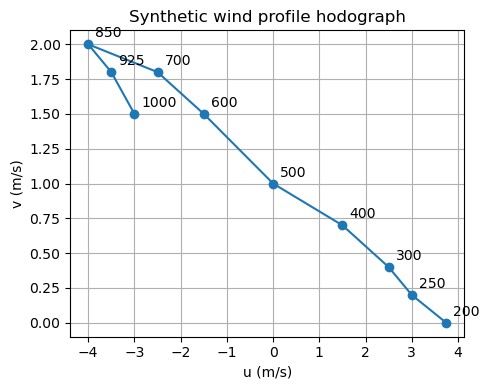

In [4]:
abs_vort = 2.0e-5  # s^-1

# Synthetic wind profile (cartoon example) reused from the VI demo.
# Values are chosen to yield ~8 m/s 850–200 hPa bulk shear magnitude.
p_wind = np.array([1000, 925, 850, 700, 600, 500, 400, 300, 250, 200], dtype=float)

# u (eastward) and v (northward), m/s.
# Low-level easterlies with slight southerly component; upper-level westerlies.
u = np.array([-3.0, -3.5, -4.0, -2.5, -1.5,  0.0,  1.5,  2.5,  3.0,  3.746], dtype=float)
v = np.array([ 1.5,  1.8,  2.0,  1.8,  1.5,  1.0,  0.7,  0.4,  0.2,  0.0  ], dtype=float)

u850, v850 = u[p_wind == 850][0], v[p_wind == 850][0]
u200, v200 = u[p_wind == 200][0], v[p_wind == 200][0]
v_shear = float(np.hypot(u850 - u200, v850 - v200))

print('|η|:', abs_vort, 's^-1')
print('850 hPa wind (u,v):', (u850, v850), 'm/s')
print('200 hPa wind (u,v):', (u200, v200), 'm/s')
print('Vshear (850–200):', v_shear, 'm/s')

plt.figure(figsize=(5, 4))
plt.plot(u, v, 'o-')
for pi, ui, vi in zip(p_wind, u, v):
    plt.text(ui + 0.15, vi + 0.05, f'{int(pi)}')
plt.xlabel('u (m/s)')
plt.ylabel('v (m/s)')
plt.title('Synthetic wind profile hodograph')
plt.grid(True)
plt.tight_layout()
plt.show()


## 4) Compute GPI

We evaluate two supported variants:
- `en04`: Emanuel & Nolan (2004)-style
- `c07`: Camargo et al. (2007)-style variant with PI thresholding (`V_PI - 35 m/s`)


In [5]:
gpi_en04 = tcpyPI.genesis_potential_index(abs_vort, rh700, v_shear, float(VMAX), formulation="en04")
gpi_c07 = tcpyPI.genesis_potential_index(abs_vort, rh700, v_shear, float(VMAX), formulation="c07")

print("GPI (en04):", float(gpi_en04))
print("GPI (c07): ", float(gpi_c07))

GPI (en04): 1.2813326670769187
GPI (c07):  0.2444561675135235


## 5) Simple sensitivity sketch

GPI is multiplicative, so it is often useful to visualize sensitivity by varying one factor at a time. Here we vary shear and humidity while holding everything else fixed.

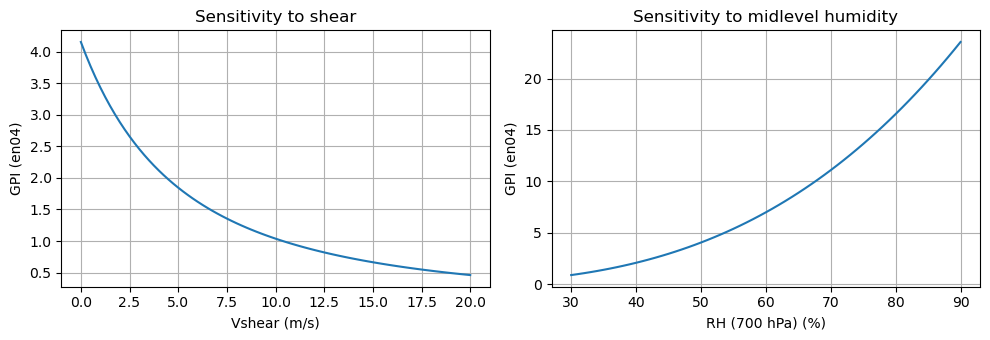

In [6]:
shears = np.linspace(0.0, 20.0, 81)
rhs = np.linspace(30.0, 90.0, 61)

gpi_vs_shear = np.array([tcpyPI.genesis_potential_index(abs_vort, rh700, vs, float(VMAX), formulation="en04") for vs in shears])
gpi_vs_rh = np.array([tcpyPI.genesis_potential_index(abs_vort, r, v_shear, float(VMAX), formulation="en04") for r in rhs])

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(shears, gpi_vs_shear)
ax[0].set_xlabel("Vshear (m/s)")
ax[0].set_ylabel("GPI (en04)")
ax[0].set_title("Sensitivity to shear")
ax[0].grid(True)

ax[1].plot(rhs, gpi_vs_rh)
ax[1].set_xlabel("RH (700 hPa) (%)")
ax[1].set_ylabel("GPI (en04)")
ax[1].set_title("Sensitivity to midlevel humidity")
ax[1].grid(True)

plt.tight_layout()
plt.show()